In [3]:
# Initialize Otter
import otter
grader = otter.Notebook("hw3-task2.ipynb")

# Homework 3 - Task 2: Tree-Based Methods
## Predicting Water Potability Using Decision Trees and Random Forests

---


### Dataset

Access to safe drinking water is a fundamental public health concern. This dataset contains physicochemical measurements for 3,276 water samples, each labeled as potable or non-potable.

| Feature | Description |
|---|---|
| `ph` | pH value of water (0–14 scale) |
| `Hardness` | Capacity to precipitate soap (mg/L) |
| `Solids` | Total dissolved solids (ppm) |
| `Chloramines` | Amount of chloramines (ppm) |
| `Sulfate` | Amount of sulfates dissolved (mg/L) |
| `Conductivity` | Electrical conductivity (μS/cm) |
| `Organic_carbon` | Amount of organic carbon (ppm) |
| `Trihalomethanes` | Amount of trihalomethanes (μg/L) |
| `Turbidity` | Measure of light-emitting property (NTU) |

#### Response Variable

| Column | Description |
|---|---|
| `Potability` | Binary flag — `1` if water is safe to drink, `0` otherwise |


 **Note:** Several features contain missing values (`ph`, `Sulfate`, `Trihalomethanes`). You will handle these in the preprocessing step.

 This dataset comes from Kaggle and can be found [here](https://www.kaggle.com/datasets/uom190346a/water-quality-and-potability).

### Setup: Load Libraries

Run the cell below to import all required packages.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

### Step 1: Load the Data

Read `water_potability.csv` into a DataFrame. Preview the first few rows and confirm its shape.

In [5]:
# Load data.
df = pd.read_csv('water_potability.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (3276, 10)


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


### Step 2: Explore the Data

Before modeling, examine the distribution of your response variable and the number of NAs. Understanding both will guide preprocessing decisions.

count    3276.000000
mean        0.390110
std         0.487849
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         1.000000
Name: Potability, dtype: float64


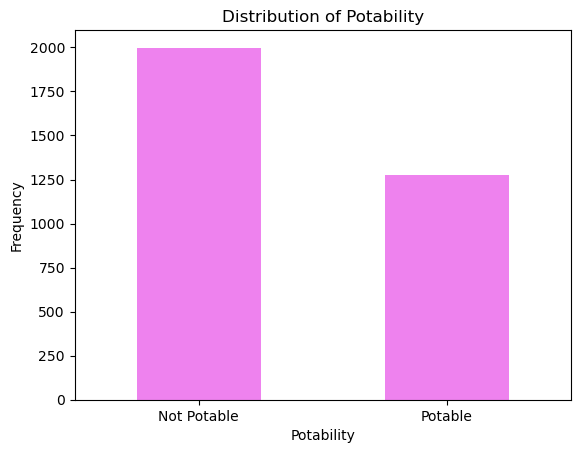

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64


In [6]:
# Examine the distribution of 'Potability'.
print(df['Potability'].describe())

# Create a bar plot of the distribution of 'Potability'.
df['Potability'].value_counts().plot(kind='bar',
                                     color='violet',
                                     xlabel='Potability',
                                     ylabel='Frequency',
                                     title='Distribution of Potability')

plt.xticks(ticks=[0, 1], 
           labels=['Not Potable', 'Potable'], 
           rotation=0)
plt.show()

# Check the number of NAs.
print(df.isnull().sum())

The response variable has more 0's or 'Not Potable' values than 1's or 'Potable' values. `ph`, `Sulfate`, and `Trihalomethanes` are the only columns that contain NA values.

### Step 3: Preprocess the Data

Three features have missing values. A simple approach for tree-based methods is to **impute with the column median**. Impute the missing values using `df.fillna()`.Store your cleaned dataframe in a variable called `df_clean`. 

After imputation, split the data 70/30 into training and test sets, stratifying on `Potability` to preserve the class ratio in both splits.Store your results in `X_train`, `X_test`, `y_train`, and `y_test`.

In [7]:
# Fill NAs with the median of each column.
df_clean = df.fillna(df.median())
features = [c for c in df_clean.columns if c != 'Potability']

# Define X and y.
X = df_clean[features]
y = df_clean['Potability']

# Split the data into training and testing sets with stratification.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [8]:
grader.check("q1")

q1 results: All test cases passed!

### Step 4: Fit a Single Classification Tree

Start with an **unpruned** classification tree (no constraints on depth or leaf size). This gives a baseline and illustrates the overfitting problem that ensemble methods address.

Fit `DecisionTreeClassifier` with only `random_state=42` set (all other parameters at defaults). Report the tree depth in a variable named `tree_depth`. Calculate both the train accuracy and the test accuracy, storing the train accuracy in a variable called`dt_unpruned_acc_train` and the test accuracy in a variable called `dt_unpruned_acc_test`. 

In [9]:
# Fit an unpruned decision tree.
dt_unpruned = DecisionTreeClassifier(random_state=42)
dt_unpruned.fit(X_train, y_train)

# Evaluate.
tree_depth = dt_unpruned.get_depth()
dt_unpruned_acc_train = accuracy_score(y_train, dt_unpruned.predict(X_train))
dt_unpruned_acc_test  = accuracy_score(y_test, dt_unpruned.predict(X_test))

print(f"Untuned tree depth: {dt_unpruned.get_depth()}")
print(f"Training accuracy: {dt_unpruned_acc_train:.3f}")
print(f"Test accuracy: {dt_unpruned_acc_test:.3f}")

Untuned tree depth: 33
Training accuracy: 1.000
Test accuracy: 0.581


In [10]:
grader.check("q2")

q2 results: All test cases passed!

<!-- BEGIN QUESTION -->

>**Q1: How does the training accuracy and test accuracy differ? What does this mean about your model?**

The training accuracy is perfect with a value of 1, compared to the lower test accuracy of 0.581. This suggest that the untuned decision tree model is overfitting the training data and producing a perfect accuracy score. It produces a lower accuracy score for the test accuracy because the test data is different from the training data. Therefore, when the model overfits the training data it cannot make generalization with other sets of data, and will produce low accuracy scores.

<!-- END QUESTION -->

### Step 5: Tune Tree Depth with Cross-Validation

A fully grown tree memorizes the training data (better training accuracy, poor test accuracy). We need to find the right **depth** to prevent this. 

Using 5-fold cross-validation on the training set, compute mean CV accuracy for `max_depth` from 1 to 20. Identify the optimal depth using `np.argmax`, storing it in a variable called `optimal_depth`. Plot the CV Accuracy against the 20 different depths, adding a vertical line at the optimal depth. 

Best max_depth (5-fold CV): 7  (CV accuracy: 0.639)


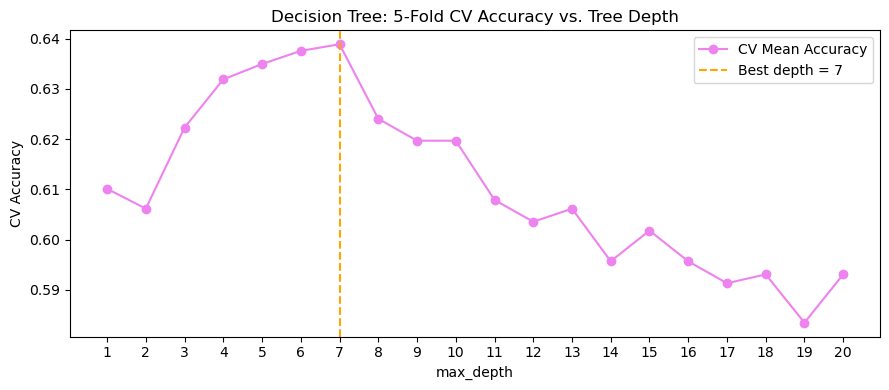

In [ ]:
# Tune max_depth with CV
depths = range(1, 21)
cv_means = []

for depth in depths:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    scores = cross_val_score(dt, X_train, y_train, cv = 5, scoring = 'accuracy')
    cv_means.append(scores.mean())

cv_means = np.array(cv_means)
optimal_depth = list(depths)[np.argmax(cv_means)]
print(f"Best max_depth (5-fold CV): {optimal_depth}  (CV accuracy: {cv_means.max():.3f})")

# Plot CV accuracy vs. max_depth.
plt.figure(figsize=(9, 4))
plt.plot(list(depths), cv_means, 
         label='CV Mean Accuracy', 
         marker='o', 
         color='violet')
plt.axvline(optimal_depth, 
            color='orange', 
            linestyle='--', 
            label=f'Best depth = {optimal_depth}')
plt.xlabel('max_depth')
plt.ylabel('CV Accuracy')
plt.xticks(list(depths))
plt.title('Decision Tree: 5-Fold CV Accuracy vs. Tree Depth')
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
grader.check("q3")

q3 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q2: What did cross fold validation find the optimal depth to be? Explain what these means in plain language.**

Cross fold validation found 7 to be the optimal depth. This means that the decision tree will go through 7 different splits before making a prediction, while also avoiding overfitting the data.

<!-- END QUESTION -->

### Step 6: Fit the Tuned Decision Tree

Refit the decision tree using `optimal_depth` and evaluate on the held-out test set. Store the test accuracy in a variable called `acc_dt`. 

In [26]:
# Fit a decision tree with the optimal depth.
dt_opt = DecisionTreeClassifier(max_depth=optimal_depth, random_state=42)
dt_opt.fit(X_train, y_train)

# Calculate the accuracy of the optimal tree on the test set.
acc_dt = accuracy_score(y_test, dt_opt.predict(X_test))
print(f"Optimal tree depth: {optimal_depth}")
print(f"Test accuracy of optimal tree: {acc_dt:.3f}")

Optimal tree depth: 7
Test accuracy of optimal tree: 0.646


In [14]:
grader.check("q4")

q4 results: All test cases passed!

<!-- BEGIN QUESTION -->

>**Q3: Did the accuracy on your tuned decision tree imrpove compared to your untuned tree? If so, why do you think it improved?**

The accuracy score of the tuned decision tree improved as it increased from 0.581 to 0.646. This improvement likely came from the fact that we found the optimal tree depth of 7, where this prevents the model from overfitting the test data and allows the model to generalizable when using other sets of data, such as the test data.

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

### Step 7: Visualize the Decision Tree

Plot the tuned tree using `plot_tree`. Save the tree as an image to evaluate the results and answer **Q5**. 

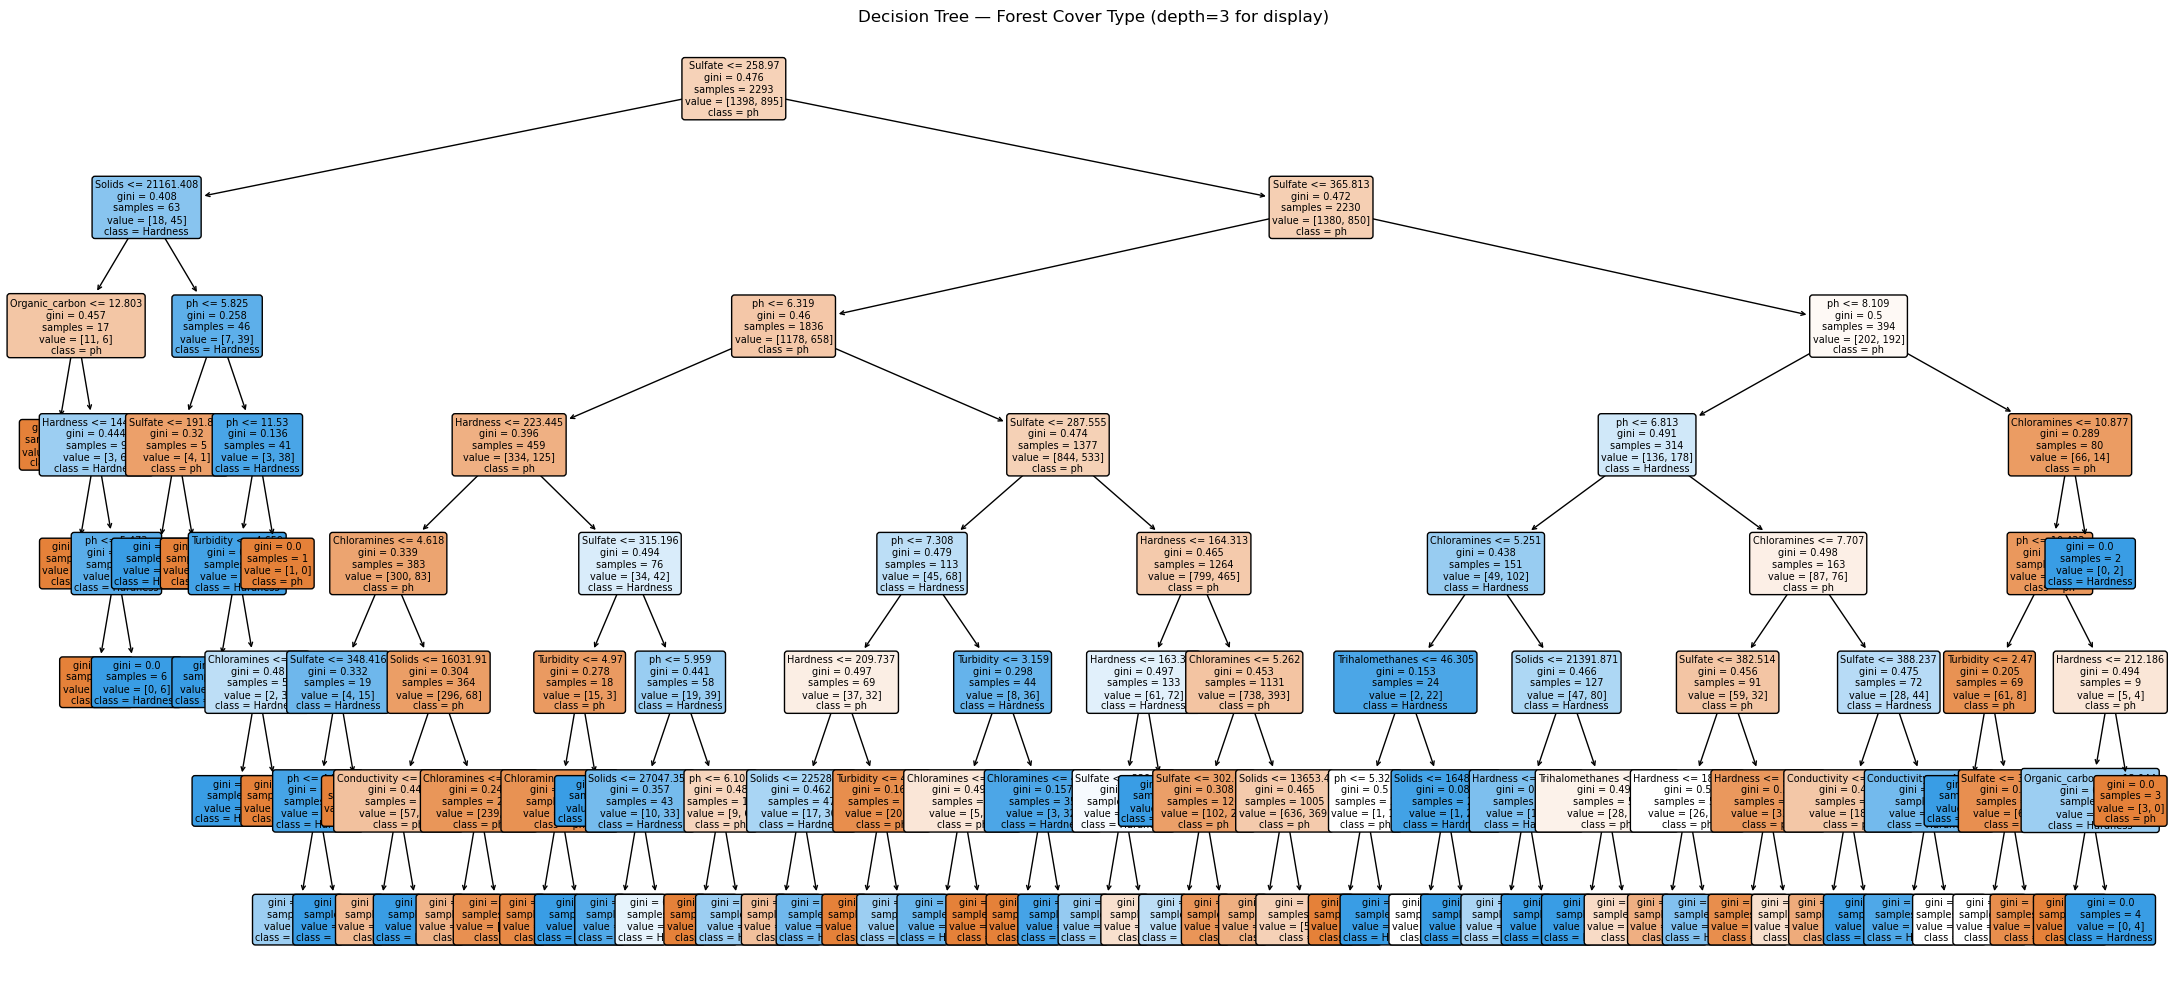

In [15]:
plt.figure(figsize=(22, 10))
class_names = ['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity']
features = class_names

# Plot tree
plot_tree(dt_opt, feature_names=features, class_names=class_names, 
          filled=True, rounded=True, fontsize=7)
          
plt.title('Decision Tree — Forest Cover Type (depth=3 for display)')
plt.tight_layout()
plt.show()

> **Q4: Examine the root node and first two levels of the tree. Which feature is used for the root split, and what threshold does it use? What does this tell you about that feature's relationship with potability? What is the Gini impurity at the root, and how does it change after the first split?**

The feature that is used for the root split is `Sulfate` with a threshold of 258.97. This tells us that the `Sulfate` is one of the strongest informative predictor for predicting `Potability`. The Gini impurity value at the root is 0.476. It decreases after the first split and continues to decrease.

<!-- END QUESTION -->

### Step 8: Random Forest

**Random forests** address the high variance of a single tree by fitting many trees on bootstrap samples of the training data and averaging their predictions. To further reduce correlation among the trees, at each split only a random subset of $m$ features is considered (by default sklearn uses $m = \lfloor\sqrt{p}\rfloor$ for classification).

Fit a `RandomForestClassifier`, called `rf` with `n_estimators=200`. Report the accuracy and store it in `acc_rf`. 

In [ ]:
# Fit a random forest.
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

# Determine the accuracy score.
acc_rf    = accuracy_score(y_test, rf.predict(X_test))
print(f"Decision Tree Accuracy: {acc_dt:.4f}")
print(f"Random Forest Accuracy: {acc_rf:.4f}")

Decision Tree Accuracy: 0.6460
Random Forest Accuracy: 0.6643


In [17]:
grader.check("q5")

q5 results:
    q5 - 1 result:
        ✅ Test case passed

    q5 - 2 result:
        ❌ Test case failed
        Trying:
            assert np.isclose(acc_rf, 0.6612, atol=0.001)
        Expecting nothing
        **********************************************************************
        Line 1, in q5 1
        Failed example:
            assert np.isclose(acc_rf, 0.6612, atol=0.001)
        Exception raised:
            Traceback (most recent call last):
              File "/opt/anaconda3/envs/eds232-env/lib/python3.10/doctest.py", line 1350, in __run
                exec(compile(example.source, filename, "single",
              File "<doctest q5 1[0]>", line 1, in <module>
                assert np.isclose(acc_rf, 0.6612, atol=0.001)
            AssertionError

<!-- BEGIN QUESTION -->

>**Q5: Compare the test results of Decision Tree and Random Forest? Which performed better? Why do you think this is?**

The `Random Forest` model performed better with an accuracy score of 0.6643. In a `Random Forest` the model fits many trees on a bootstrap sample of the training data. The model fits many trees on a bootstrap sample of the training data, where a random subset of m features are considered at each split, this further reduces correlation among the trees. And by averaging the predictions of the many fit trees, noise in the model is addressed and the overall variance is reduced.

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

### Step 9: Feature Importances

Both decision trees and random forests assign an **importance score** to each feature based on the total reduction in impurity (Gini) it produces across all splits. Random forest importances are averaged over all trees in the ensemble, making them more stable than a single tree's importances.

Create a bar plot showing the feature importances from the tuned decision tree and the random forest side by side. You can access the feature importants from the model wtih `model.feature_importances_`.

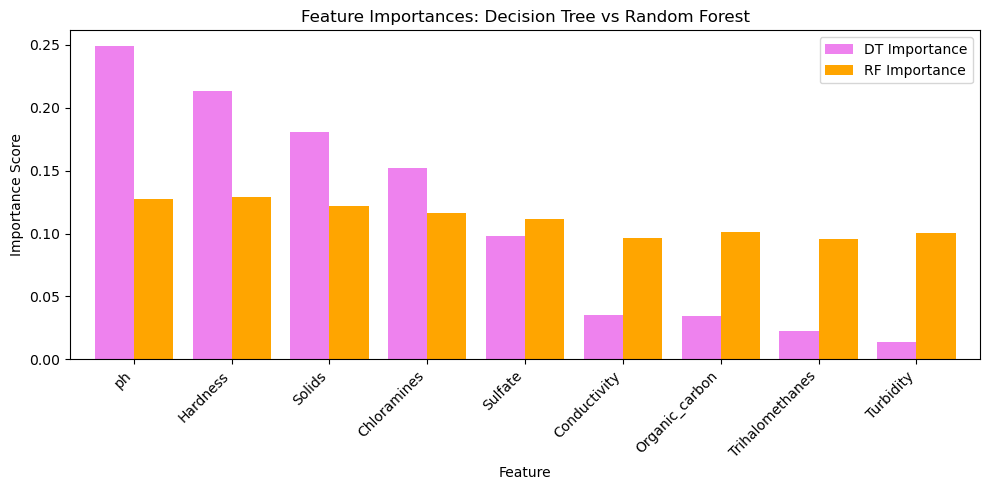

In [35]:
# Plot feature importances for both models.

importance_df = pd.DataFrame({
    'Feature': class_names,
    'DT Importance': dt_opt.feature_importances_,
    'RF Importance': rf.feature_importances_
}).sort_values(by='DT Importance', ascending=False)

ax = importance_df.plot.bar(figsize = (10,5), width=0.8, color=['violet', 'orange'])
ax.set_xticklabels(features, rotation = 45, ha = 'right')
ax.set_title('Feature Importances: Decision Tree vs Random Forest')
plt.ylabel('Importance Score')
plt.xlabel('Feature')
plt.tight_layout()
plt.show()

> **Q6: Do the decision tree and random forest agree on which features are most important? If they differ, why might a single tree's importances be less reliable than the random forest's? Which feature appears most important for predicting potability, and does that make physical sense?**

The `Decision Tree` and `Random Forest` models agree on `ph`, `Hardness`, `Solids` and `Chloramines` being the most important features. A singe tree's importance can be less reliable than a random forest's since it splits early on the most important features such as `pH` and `Hardness`, when other features may have a signal. While a `Random Forest` assess the features across many different bootstrap samples and random combinations of feature subsets, which allows for other features signals who may be "less" important to be seen. `pH` being the most important for predicting potability makes physical sense being that water being too acidic is unsafe for human health.

<!-- END QUESTION -->

### Step 10: Confusion Matrix

Create a confusion matrix for the random forest model using `ConfusionMatrixDisplay`. Label your response variable as `Not Potable`/ `Potable` in the confusion matrix (instead of `0`/`1`).

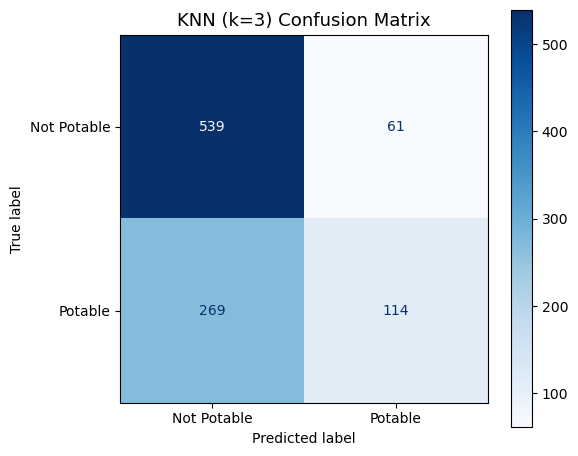

In [36]:
cm = confusion_matrix(y_test, rf.predict(X_test))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                              display_labels=['Not Potable', 'Potable'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title('KNN (k=3) Confusion Matrix', fontsize=13)
plt.tight_layout()
plt.show()

<!-- BEGIN QUESTION -->

> **Q7:** Report the results of the confusion matrix. How many false positives, true positives, false negatives, and true negatives did your model predict? Interpret what each of those 4 results means in the context of the data.

False Positives: 61, Water predicted as Potable is actually Not Potable.
True Positive: 114, Water predicted as Potable is actually Potable.
False Negatives: 269, Water predicted as Not Potable is actually Potable.
True Negatives: 539, Water predicted as Not Potable is actually Not Potable.

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

### Step 11: Model Comparison

Create a table or bar chart comparing test accuracy across all three models.

In [ ]:
# Create table of test accuracy scores.
summary_df = pd.DataFrame({
    'Model': ['Unpruned Decision Tree', 'Tuned Decision Tree', 'Random Forest'],
    'Test Accuracy': [dt_unpruned_acc_test, acc_dt, acc_rf]
})

print(summary_df)

                    Model  Test Accuracy
0  Unpruned decision tree       0.580875
1     Tuned decision tree       0.645982
2           Random forest       0.664293


> **Q8:** Which model achieved the highest test accuracy? Comparing the unpruned and tuned decision tree, how much did pruning improve accuracy? What does this tell you about overfitting in the unpruned tree?

The model that achieved the highest test accuracy was the `Random Forest`, with a value of 0.664293. The accuracy score between the `Unpruned` and `Tuned` Decision Tree increased from 0.580875 to 0.645982. This tells us that `Unpruned` tree memorized and overfit the training data, achieving perfect training accuracy but only 0.581 on the test data. Meaning that while the `Unpruned` model may have had a high accuracy score, the model is not generalizable to other data sets. After determining an optimal depth for the `Tuned` Decision Tree, we avoid over fitting the data and allow the model to be more generalizable to other data sets, such as the test data. Therefore, producing a higher test accuracy score for the `Tuned` Decision Tree model.

---

Run the cell below to receive credit for autograded questions. 

In [21]:
grader.check_all()

q1 results: All test cases passed!

q2 results: All test cases passed!

q3 results: All test cases passed!

q4 results: All test cases passed!

q5 results:
    q5 - 1 result:
        ✅ Test case passed

    q5 - 2 result:
        ❌ Test case failed
        Trying:
            assert np.isclose(acc_rf, 0.6612, atol=0.001)
        Expecting nothing
        **********************************************************************
        Line 1, in q5 1
        Failed example:
            assert np.isclose(acc_rf, 0.6612, atol=0.001)
        Exception raised:
            Traceback (most recent call last):
              File "/opt/anaconda3/envs/eds232-env/lib/python3.10/doctest.py", line 1350, in __run
                exec(compile(example.source, filename, "single",
              File "<doctest q5 1[0]>", line 1, in <module>
                assert np.isclose(acc_rf, 0.6612, atol=0.001)
            AssertionError